In [ ]:
!pip install kagglehub -q

import kagglehub
path = kagglehub.dataset_download("nibinv23/iam-handwriting-word-database")
print("Path to dataset files:", path)

Resuming download from 169869312 bytes (1014151103 bytes left)...
Resuming download to /root/.cache/kagglehub/datasets/nibinv23/iam-handwriting-word-database/2.archive (169869312/1184020415) bytes left.


100%|██████████| 1.10G/1.10G [00:11<00:00, 87.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nibinv23/iam-handwriting-word-database/versions/2


In [ ]:
!pip install opencv-python

In [ ]:
!pip install tensorflow

In [ ]:
# Cell 1
import os
import cv2
import numpy as np
import pandas as pd

WORDS_IMG_DIR = os.path.join(path, 'iam_words', 'words')
WORDS_TXT = os.path.join(path, 'iam_words', 'words.txt')

print(WORDS_IMG_DIR)
print(WORDS_TXT)

/root/.cache/kagglehub/datasets/nibinv23/iam-handwriting-word-database/versions/2/iam_words/words
/root/.cache/kagglehub/datasets/nibinv23/iam-handwriting-word-database/versions/2/iam_words/words.txt


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cell 2:
def parse_words_txt(path):
    data = []
    skipped = 0
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('#') or not line:
                continue
            parts = line.split()
            if len(parts) < 9:
                skipped += 1
                continue
            word_id = parts[0]
            status = parts[1]
            transcription = parts[-1]
            if status != 'ok':
                continue
            folder1 = word_id.split('-')[0]
            folder2 = '-'.join(word_id.split('-')[:2])
            img_path = os.path.join(WORDS_IMG_DIR, folder1, folder2, word_id + '.png')
            data.append({'id': word_id, 'img_path': img_path, 'label': transcription})
    print(f"Skipped malformed lines: {skipped}")
    return pd.DataFrame(data)

df = parse_words_txt(WORDS_TXT)
print(f"Total usable samples: {len(df)}")
df.head()

Skipped malformed lines: 1
Total usable samples: 38305


,id,img_path,label
0,a01-000u-00-00,/root/.cache/kagglehub/datasets/nibinv23/iam-h...,A
1,a01-000u-00-01,/root/.cache/kagglehub/datasets/nibinv23/iam-h...,MOVE
2,a01-000u-00-02,/root/.cache/kagglehub/datasets/nibinv23/iam-h...,to
3,a01-000u-00-03,/root/.cache/kagglehub/datasets/nibinv23/iam-h...,stop
4,a01-000u-00-04,/root/.cache/kagglehub/datasets/nibinv23/iam-h...,Mr.


In [ ]:
# Cell 3a: Filter out missing/invalid image paths
def is_valid(row):
    return os.path.exists(row['img_path']) and len(row['label']) <= 24

df = df[df.apply(is_valid, axis=1)].reset_index(drop=True)
print(f"Valid samples after filtering: {len(df)}")

Valid samples after filtering: 38305


In [ ]:
# Cell 3b:
def is_valid_deep(row):
    path = row['img_path']
    if not os.path.exists(path):
        return False
    if os.path.getsize(path) == 0:
        return False
    return True

before = len(df)
df = df[df.apply(is_valid_deep, axis=1)].reset_index(drop=True)
print(f"Removed {before - len(df)} zero-byte/missing files. Remaining: {len(df)}")

Removed 1 zero-byte/missing files. Remaining: 38304


In [ ]:
# Cell 3c
from PIL import Image
from tqdm import tqdm

def is_decodable(path):
    try:
        img = Image.open(path)
        img.verify()
        return True
    except Exception:
        return False

tqdm.pandas()
mask = df['img_path'].progress_apply(is_decodable)
before = len(df)
df = df[mask].reset_index(drop=True)
print(f"Removed {before - len(df)} corrupted/undecodable files. Remaining: {len(df)}")

100%|██████████| 38304/38304 [00:18<00:00, 2073.60it/s]

Removed 0 corrupted/undecodable files. Remaining: 38304


In [ ]:
# Cell 3d
import tensorflow as tf
from tqdm import tqdm

def is_tf_decodable(path):
    try:
        img_bytes = tf.io.read_file(path)
        if tf.strings.length(img_bytes) == 0:
            return False
        img = tf.image.decode_png(img_bytes, channels=1)
        return True
    except Exception:
        return False

tqdm.pandas()
mask = df['img_path'].progress_apply(is_tf_decodable)
before = len(df)
df = df[mask].reset_index(drop=True)
print(f"Removed {before - len(df)} files that TF couldn't decode. Remaining: {len(df)}")

100%|██████████| 38304/38304 [00:56<00:00, 674.67it/s]

Removed 0 files that TF couldn't decode. Remaining: 38304


In [ ]:
# Cell 3e:
import shutil
import os

LOCAL_DIR = "/content/iam_words"

if not os.path.exists(LOCAL_DIR):
    print("Copying dataset to local disk — this will take a few minutes...")
    shutil.copytree(os.path.join(path, "iam_words"), LOCAL_DIR)
    print("Done.")
else:
    print("Already copied.")

Copying dataset to local disk — this will take a few minutes...
Done.


In [ ]:
# Cell 3f:
WORDS_IMG_DIR = os.path.join(LOCAL_DIR, "words")

def rebuild_path(word_id):
    folder1 = word_id.split('-')[0]
    folder2 = '-'.join(word_id.split('-')[:2])
    return os.path.join(WORDS_IMG_DIR, folder1, folder2, word_id + '.png')

df['img_path'] = df['id'].apply(rebuild_path)
print(df['img_path'].iloc[0])
print(os.path.exists(df['img_path'].iloc[0]))

/content/iam_words/words/a01/a01-000u/a01-000u-00-00.png
True


In [ ]:
WORDS_IMG_DIR = os.path.join(LOCAL_DIR, "words")

def rebuild_path(word_id):
    folder1 = word_id.split('-')[0]
    folder2 = '-'.join(word_id.split('-')[:2])
    return os.path.join(WORDS_IMG_DIR, folder1, folder2, word_id + '.png')

df['img_path'] = df['id'].apply(rebuild_path)
print(df['img_path'].iloc[0])
print(os.path.exists(df['img_path'].iloc[0]))

/content/iam_words/words/a01/a01-000u/a01-000u-00-00.png
True


In [ ]:
# Cell 4:
all_chars = sorted(set(''.join(df['label'].tolist())))
char_to_idx = {c: i + 1 for i, c in enumerate(all_chars)}
idx_to_char = {i + 1: c for i, c in enumerate(all_chars)}
vocab_size = len(all_chars) + 1

print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {all_chars}")

Vocabulary size: 77
Characters: ['!', '"', '#', "'", '(', ')', '*', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [ ]:
# Cell 5:
IMG_HEIGHT = 32
IMG_WIDTH = 128

def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    h, w = img.shape
    new_w = int(w * (IMG_HEIGHT / h))
    img = cv2.resize(img, (new_w, IMG_HEIGHT))
    if new_w < IMG_WIDTH:
        pad = np.ones((IMG_HEIGHT, IMG_WIDTH - new_w), dtype=np.uint8) * 255
        img = np.concatenate([img, pad], axis=1)
    else:
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img.astype(np.float32) / 255.0
    return img

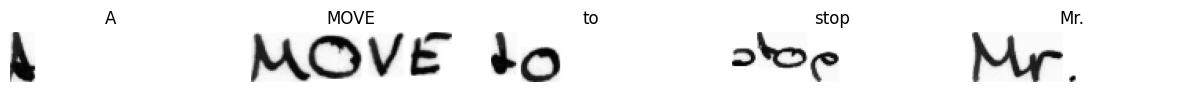

In [ ]:
# Cell 6:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    row = df.iloc[i]
    img = preprocess_image(row['img_path'])
    ax.imshow(img, cmap='gray')
    ax.set_title(row['label'])
    ax.axis('off')
plt.show()

In [ ]:
# Cell 7:
MAX_LABEL_LEN = 24
def encode_label(text):
    return [char_to_idx[c] for c in text]

def decode_label(indices):
    return ''.join([idx_to_char[i] for i in indices if i in idx_to_char])

sample_label = df.iloc[0]['label']
encoded = encode_label(sample_label)
decoded = decode_label(encoded)
print(f"Original: {sample_label}")
print(f"Encoded: {encoded}")
print(f"Decoded: {decoded}")

Original: A
Encoded: [25]
Decoded: A


In [ ]:
# Cell 8:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

Train samples: 34473
Validation samples: 3831


In [ ]:
# Cell 9:
import tensorflow as tf

def encode_single_sample(img_path, label):

    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.transpose(img, perm=[1, 0, 2])

    label = tf.strings.unicode_split(label, input_encoding="UTF-8")
    label = tf.map_fn(lambda c: char_to_idx_table.lookup(c), label, fn_output_signature=tf.int64)

    return img, label

keys = list(char_to_idx.keys())
values = list(char_to_idx.values())
char_to_idx_table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(keys, values, key_dtype=tf.string, value_dtype=tf.int64),
    default_value=-1
)

BATCH_SIZE = 32

def make_dataset(dataframe):
    img_paths = dataframe['img_path'].values
    labels = dataframe['label'].values
    dataset = tf.data.Dataset.from_tensor_slices((img_paths, labels))
    dataset = dataset.map(encode_single_sample, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.padded_batch(
        BATCH_SIZE,
        padded_shapes=([IMG_WIDTH, IMG_HEIGHT, 1], [MAX_LABEL_LEN]),
        padding_values=(0.0, tf.cast(0, tf.int64))
    )
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_dataset = make_dataset(train_df)
val_dataset = make_dataset(val_df)

print("Train dataset:", train_dataset)
print("Val dataset:", val_dataset)

Train dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 32, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 24), dtype=tf.int64, name=None))>
Val dataset: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 32, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 24), dtype=tf.int64, name=None))>


In [ ]:
# Cell 10:
for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Sample label (encoded):", labels[0].numpy())
    print("Sample label (decoded):", decode_label(labels[0].numpy()))

Image batch shape: (32, 128, 32, 1)
Label batch shape: (32, 24)
Sample label (encoded): [51 62 62 65 73  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
Sample label (decoded): allow


In [ ]:
# Cell 11:
from tensorflow.keras import layers, Model

def build_crnn_model(img_width=IMG_WIDTH, img_height=IMG_HEIGHT, vocab_size=vocab_size):
    input_img = layers.Input(shape=(img_width, img_height, 1), name="image")

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
    x = layers.MaxPooling2D((1, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((1, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((1, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)

    new_shape = (img_width, (img_height // 8) * 128)
    x = layers.Reshape(target_shape=new_shape)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.25))(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.25))(x)

    x = layers.Dense(vocab_size + 1, activation="softmax", name="dense_output")(x)

    model = Model(inputs=input_img, outputs=x, name="crnn_model")
    return model

model = build_crnn_model()
model.summary()

Model: "crnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 128, 32, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 32, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 16, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 16, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 8, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 8, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 8, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 4, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 4, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 4, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 128, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128, 64)        │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128, 256)       │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128, 128)       │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_output (Dense)            │ (None, 128, 78)        │        10,062 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646,158 (2.46 MB)

 Trainable params: 645,646 (2.46 MB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
# Cell 12
def ctc_loss_fn(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    loss = tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)
    return loss

In [ ]:
# Cell 13:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss=ctc_loss_fn)

In [ ]:

# Cell 14:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint_cb = ModelCheckpoint(
    "crnn_best.keras",
    save_best_only=True,
    monitor="val_loss",
    mode="min"
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [ ]:
# Cell 15:
EPOCHS = 5

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint_cb, early_stop_cb, reduce_lr_cb]
)

Epoch 1/5
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 126s 101ms/step - loss: 19.0350 - val_loss: 19.6331 - learning_rate: 0.0010
Epoch 2/5
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 113s 105ms/step - loss: 14.9079 - val_loss: 15.1991 - learning_rate: 0.0010
Epoch 3/5
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 116s 108ms/step - loss: 14.0161 - val_loss: 17.0245 - learning_rate: 0.0010
Epoch 4/5
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 107s 99ms/step - loss: 13.2162 - val_loss: 13.6841 - learning_rate: 0.0010
Epoch 5/5
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 115s 107ms/step - loss: 12.4645 - val_loss: 12.1007 - learning_rate: 0.0010


In [ ]:
model.save('/content/drive/MyDrive/handwriting_model.keras')

In [ ]:
import os
print(os.path.exists('/content/drive/MyDrive/handwriting_model.keras'))

True


In [ ]:
# Cell 16:

def ctc_decode_predictions(pred):
    input_len = np.ones(pred.shape[0]) * pred.shape[1]
    results = tf.keras.backend.ctc_decode(pred, input_length=input_len, greedy=True)[0][0]
    output_texts = []
    for res in results:
        res = res.numpy()
        res = res[res != -1]
        text = decode_label(res)
        output_texts.append(text)
    return output_texts

def levenshtein(a, b):
    m, n = len(a), len(b)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + cost)
    return dp[m][n]

def compute_cer(pred, true):
    if len(true) == 0:
        return 0 if len(pred) == 0 else 1
    return levenshtein(pred, true) / len(true)

total_cer = 0
total_samples = 0
exact_matches = 0

for images, labels in val_dataset:
    preds = model.predict(images, verbose=0)
    pred_texts = ctc_decode_predictions(preds)
    true_texts = [decode_label(l.numpy()) for l in labels]

    for pred_text, true_text in zip(pred_texts, true_texts):
        cer = compute_cer(pred_text, true_text)
        total_cer += cer
        total_samples += 1
        if pred_text == true_text:
            exact_matches += 1

avg_cer = total_cer / total_samples
word_accuracy = exact_matches / total_samples

print(f"Average CER: {avg_cer:.4f}")
print(f"Word-level accuracy: {word_accuracy:.4f} ({exact_matches}/{total_samples})")

Average CER: 0.5974
Word-level accuracy: 0.2159 (827/3831)


In [ ]:
from google.colab import files
import matplotlib.pyplot as plt
import tensorflow as tf

Saving Screenshot 2026-09-21 230148.png to Screenshot 2026-09-21 230148.png


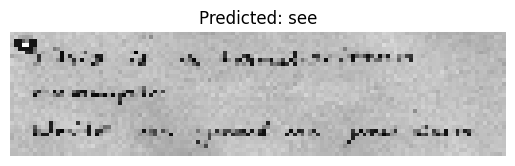

File: Screenshot 2026-09-21 230148.png → Predicted text: see


In [ ]:
# Cell 17:
uploaded = files.upload()

for fname in uploaded.keys():
    img_path = fname

    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1) if img_path.lower().endswith('png') else tf.image.decode_jpeg(img, channels=1)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.transpose(img, perm=[1, 0, 2])
    img_batch = tf.expand_dims(img, axis=0)

    pred = model.predict(img_batch, verbose=0)
    pred_text = ctc_decode_predictions(pred)[0]

    plt.imshow(tf.transpose(img, perm=[1, 0, 2]).numpy().squeeze(), cmap='gray')
    plt.title(f"Predicted: {pred_text}")
    plt.axis('off')
    plt.show()

    print(f"File: {fname} → Predicted text: {pred_text}")

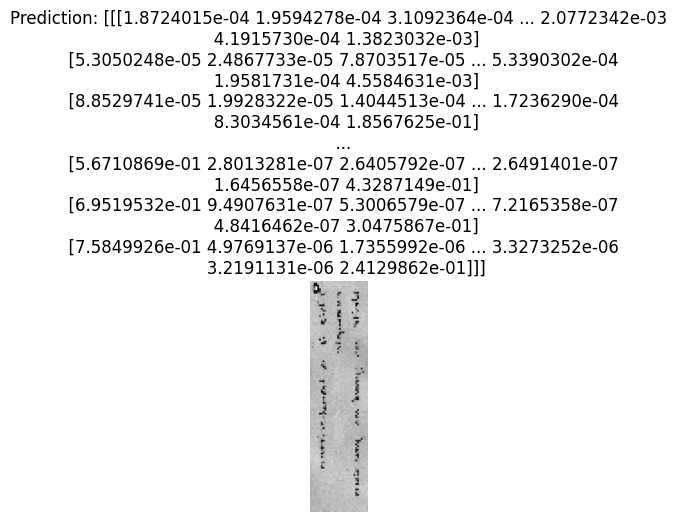

In [ ]:
plt.figure(figsize=(8, 3))
plt.imshow(img, cmap="gray")
plt.title(f"Prediction: {pred}")
plt.axis("off")
plt.savefig('/content/drive/MyDrive/prediction_result.png', bbox_inches='tight')
plt.show()

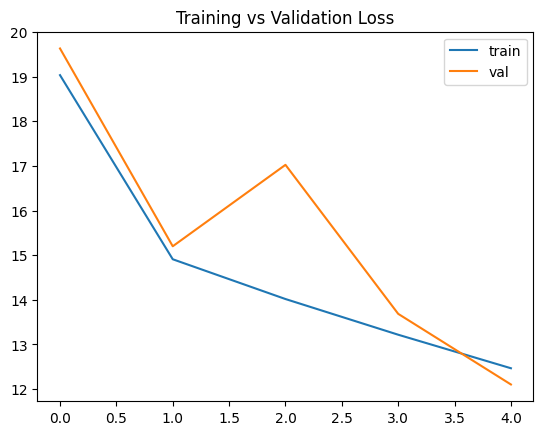

In [ ]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()